# 02 | Where is this asset, and what is nearby?
**35 minutes · Spatial joins and distance**

**By the end:** attach area attributes to points, retain unmatched assets, and measure distance using a suitable projected CRS.

**Case question:** Which service area contains each asset, and which sites lie close to a transport corridor?
The corridor and areas are fictional and are **not flood zones** or evidence of transport access.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the project root or a subfolder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/assets.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Keep the notebooks and data folders together; open this project in Jupyter.')
DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
print('Ready. Core lessons use bundled local data; no API key needed.')

Ready. Core lessons use bundled local data; no API key needed.


In [2]:
import geopandas as gpd
from shapely.geometry import Point
points = gpd.read_file(DATA / 'assets.geojson')
zones = gpd.read_file(DATA / 'service_areas.geojson')
roads = gpd.read_file(DATA / 'corridor.geojson')
assert points.crs == zones.crs == roads.crs
assert zones.geometry.is_valid.all()

## 1. Join by place rather than by a shared name
A spreadsheet join matches an ID. A **spatial join** matches a relationship such as “point lies inside polygon.”
`how='left'` keeps every asset; `predicate='within'` requires the point to be in the polygon's interior.

**Predict:** Should an asset outside both polygons disappear from our portfolio?

In [3]:
joined = gpd.sjoin(points, zones[['zone_name','geometry']], how='left', predicate='within')
joined['zone_name'] = joined.zone_name.fillna('Outside supplied areas')
assert len(joined) == len(points)  # Our example polygons do not overlap.
display(joined[['asset_id','asset_name','zone_name']])
summary = joined.groupby('zone_name').agg(assets=('asset_id','count'), equity_usd_m=('equity_usd_m','sum'))
display(summary)
assert summary.equity_usd_m.sum() == points.equity_usd_m.sum()

,asset_id,asset_name,zone_name
0,A01,Bay warehouse,West service area
1,A02,Canal apartments,West service area
2,A03,Cedar logistics,East service area
3,A04,Delta solar,East service area
4,A05,Elm housing,West service area
5,A06,Foundry storage,West service area
6,A07,Grove office,East service area
7,A08,Harbor data center,East service area
8,A09,Ivy apartments,West service area
9,A10,Juniper depot,East service area


,assets,equity_usd_m
zone_name,,
East service area,5,161
Outside supplied areas,1,30
West service area,6,150


## 2. A boundary is a decision, too
A point exactly on a shared boundary is not `within` either polygon. `intersects` can match it to both. Overlapping polygons can also duplicate rows. Before summing money, inspect match counts and define an explicit assignment rule.

In [4]:
boundary_point = Point(-95.35,29.75)
display(pd.DataFrame({'zone':zones.zone_name,
                     'within':[boundary_point.within(g) for g in zones.geometry],
                     'intersects':[boundary_point.intersects(g) for g in zones.geometry]}))

,zone,within,intersects
0,West service area,False,True
1,East service area,False,True


## 3. Degrees are not metres
For this compact example near Houston we use **UTM zone 15N (`EPSG:32615`)**, a projected coordinate system whose units are metres. It is a local choice, not a universal solution.

`set_crs` labels what coordinates already mean; `to_crs` transforms the coordinates. Relabelling degrees as metres would be wrong. See the [GeoPandas projection guide](https://geopandas.org/en/stable/docs/user_guide/projections.html).

In [5]:
points_m = points.to_crs('EPSG:32615')
roads_m = roads.to_crs(points_m.crs)
corridor = roads_m.geometry.union_all()
points_m['distance_km'] = points_m.geometry.distance(corridor)/1000
nearby_km = 3.0  # TRY: 1.0 or 5.0
points_m['near_corridor'] = points_m.distance_km <= nearby_km
display(points_m[['asset_id','distance_km','near_corridor']].round(2))

,asset_id,distance_km,near_corridor
0,A01,0.18,True
1,A02,0.41,True
2,A03,3.77,False
3,A04,12.42,False
4,A05,9.77,False
5,A06,6.24,False
6,A07,5.82,False
7,A08,5.95,False
8,A09,13.94,False
9,A10,2.06,True


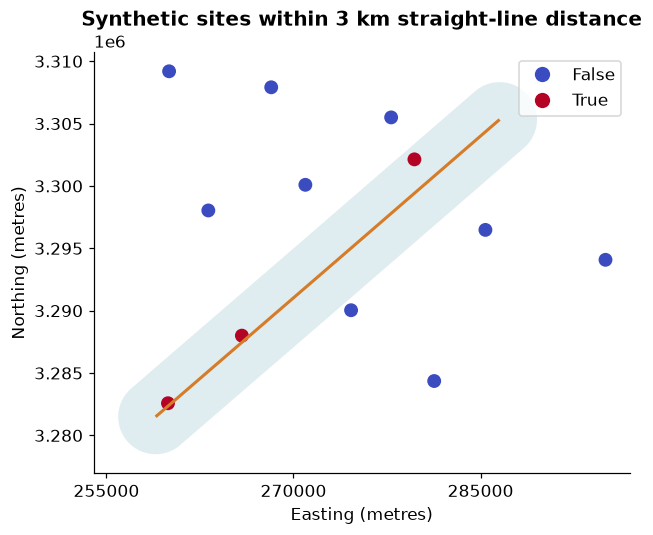

In [6]:
fig, ax = plt.subplots()
gpd.GeoSeries([corridor.buffer(nearby_km*1000)],crs=points_m.crs).plot(ax=ax,color='#dfedf0')
roads_m.plot(ax=ax,color='#d67b27',linewidth=2,label='Fictional corridor')
points_m.plot(ax=ax,column='near_corridor',categorical=True,legend=True,cmap='coolwarm',markersize=65)
ax.set(xlabel='Easting (metres)',ylabel='Northing (metres)',
       title=f'Synthetic sites within {nearby_km:g} km straight-line distance')
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()
plt.show()

## Try it · 5 minutes
1. Change the distance threshold from 3 km to 1 km. Does the selected group grow or shrink?
2. Explain why straight-line proximity is not driving time, road access, or a causal explanation of asset performance.
3. Why is “outside supplied areas” different from “no exposure”?

**Coding extension:** calculate equity by area using an inner join, compare the total with the left join, and explain what went missing. Build a table of asset counts and equity within 1, 3 and 5 km of the corridor. Check that counts cannot fall as the radius increases.

**Takeaway:** spatial matching is an analytical choice. Boundaries, projection and missing matches can change portfolio summaries.